Titanic - Machine Learning from Disaster,
Goal : To find out which type of passengers are more likely to survive.

Tools Used
Python, Pandas, Matplotlib, Seaborn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
#to find null values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
X = df.drop('Survived', axis = 1)
y = df['Survived']

EDA

<Axes: xlabel='Survived', ylabel='count'>

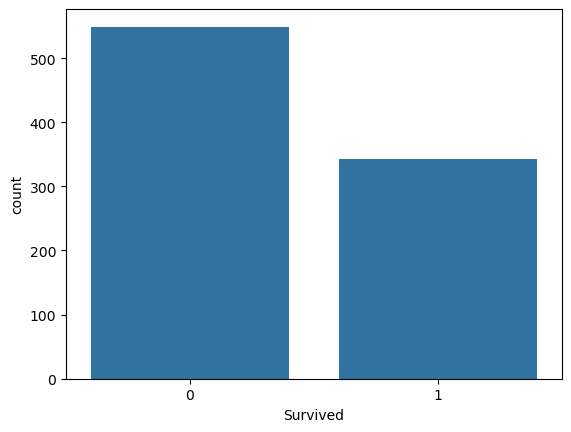

In [9]:
#countplot shows how many values exis in each category 
# 0 - not survived , 1- survived (We can see number of ppl survived is less compared to survived this imbalance might affect our model)
sns.countplot(x = y, data = df)

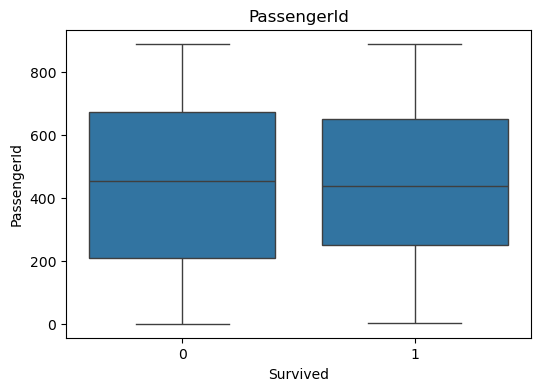

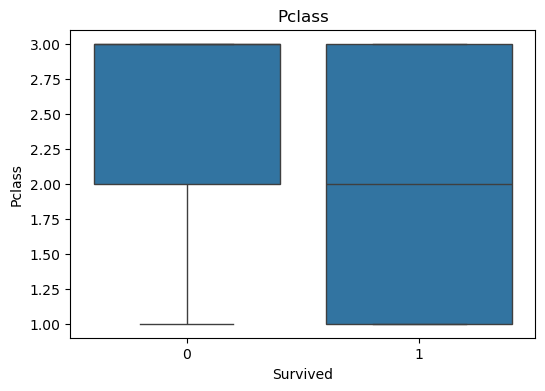

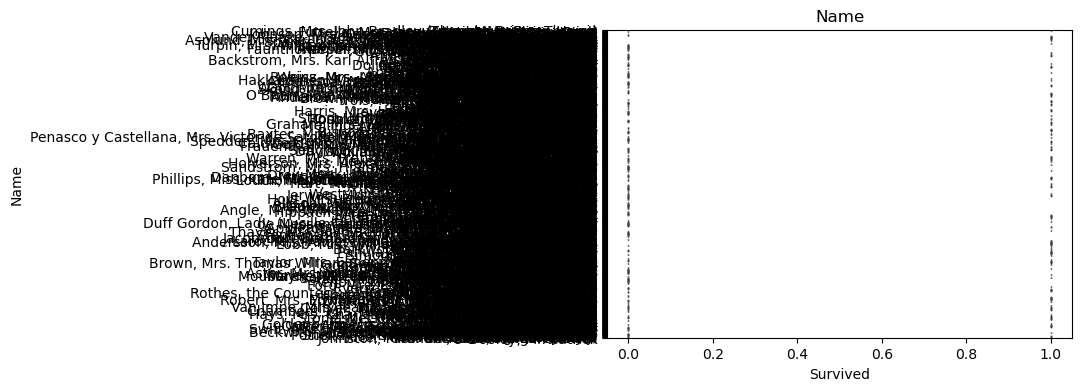

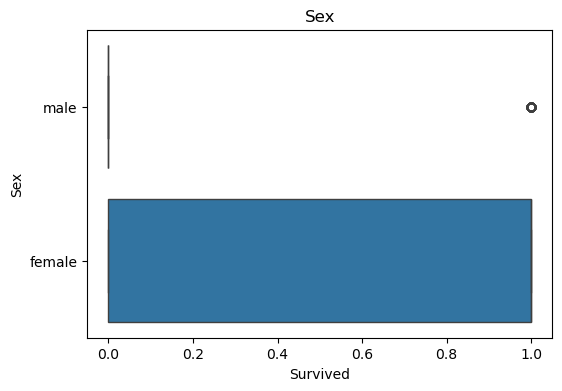

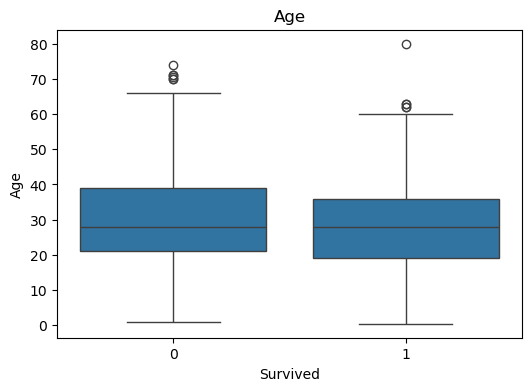

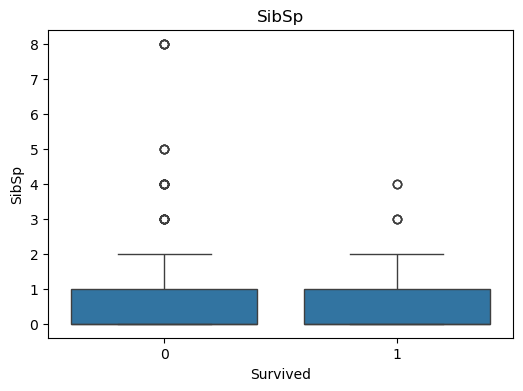

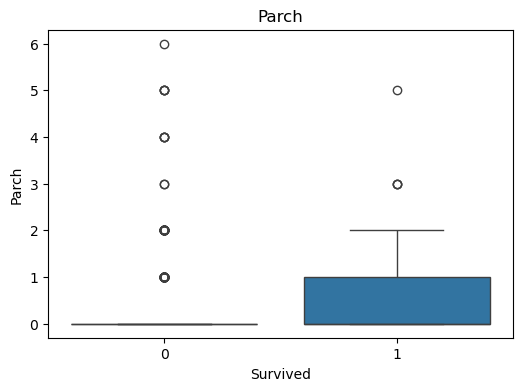

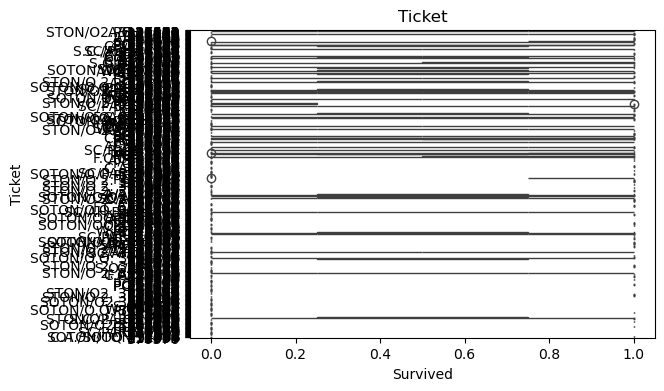

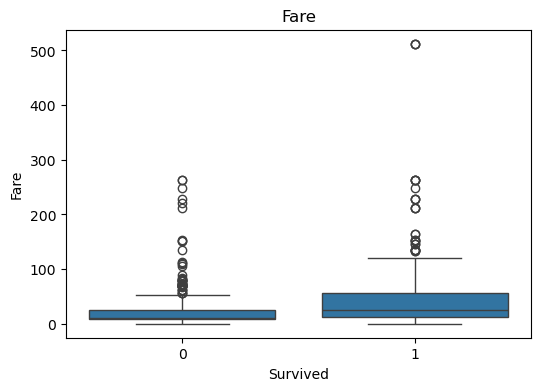

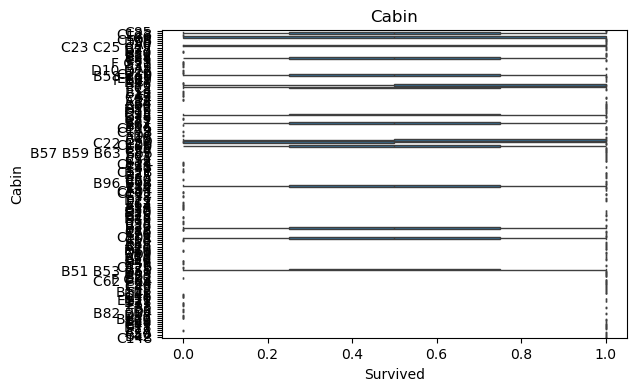

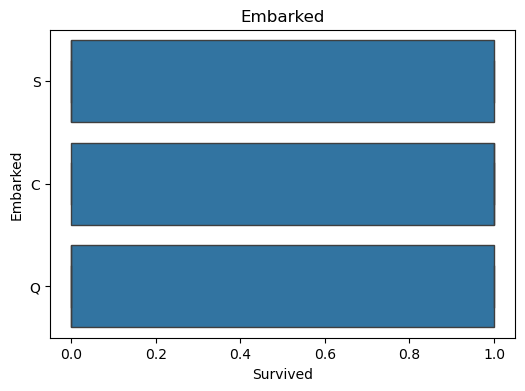

In [10]:
for col in X.columns:
    plt.figure(figsize=(6,4)) 
    sns.boxplot(x=y, y=df[col]) 
    plt.title(col) 
    plt.show()

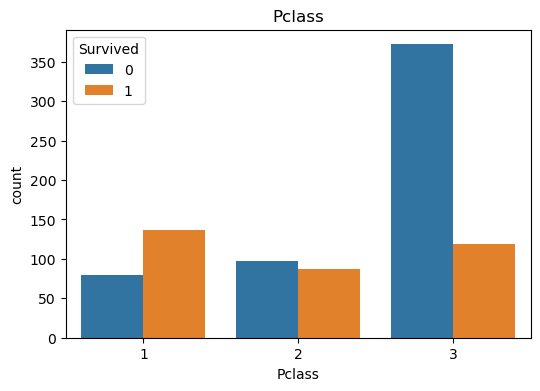

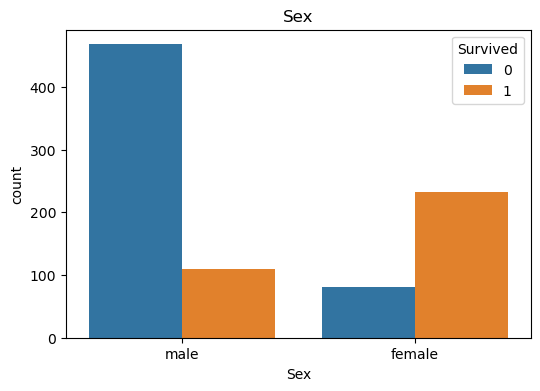

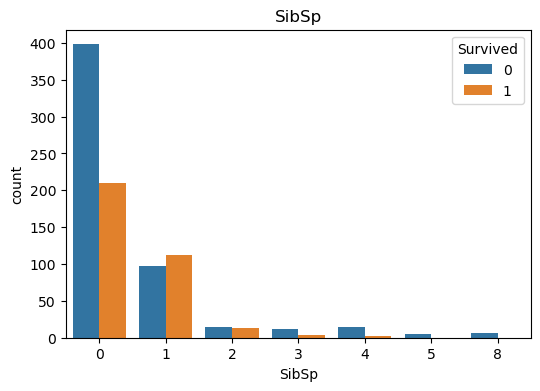

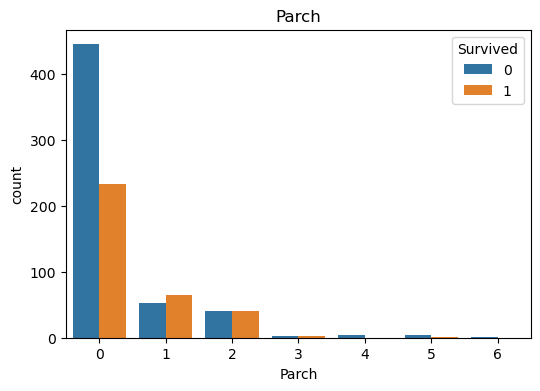

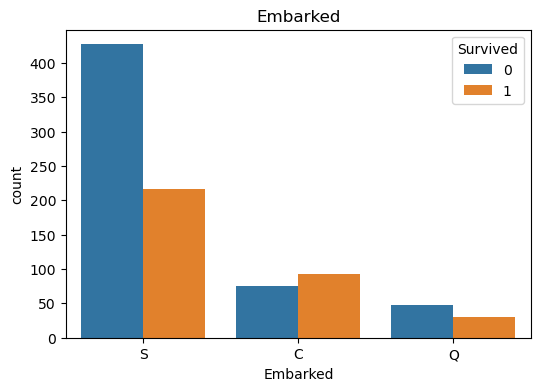

In [11]:
list = df[['Pclass','Sex','SibSp','Parch','Embarked']]
for col in list: 
    plt.figure(figsize=(6,4))
    sns.countplot(x = col ,hue = 'Survived' , data = df)
    plt.title(col)
    plt.show()

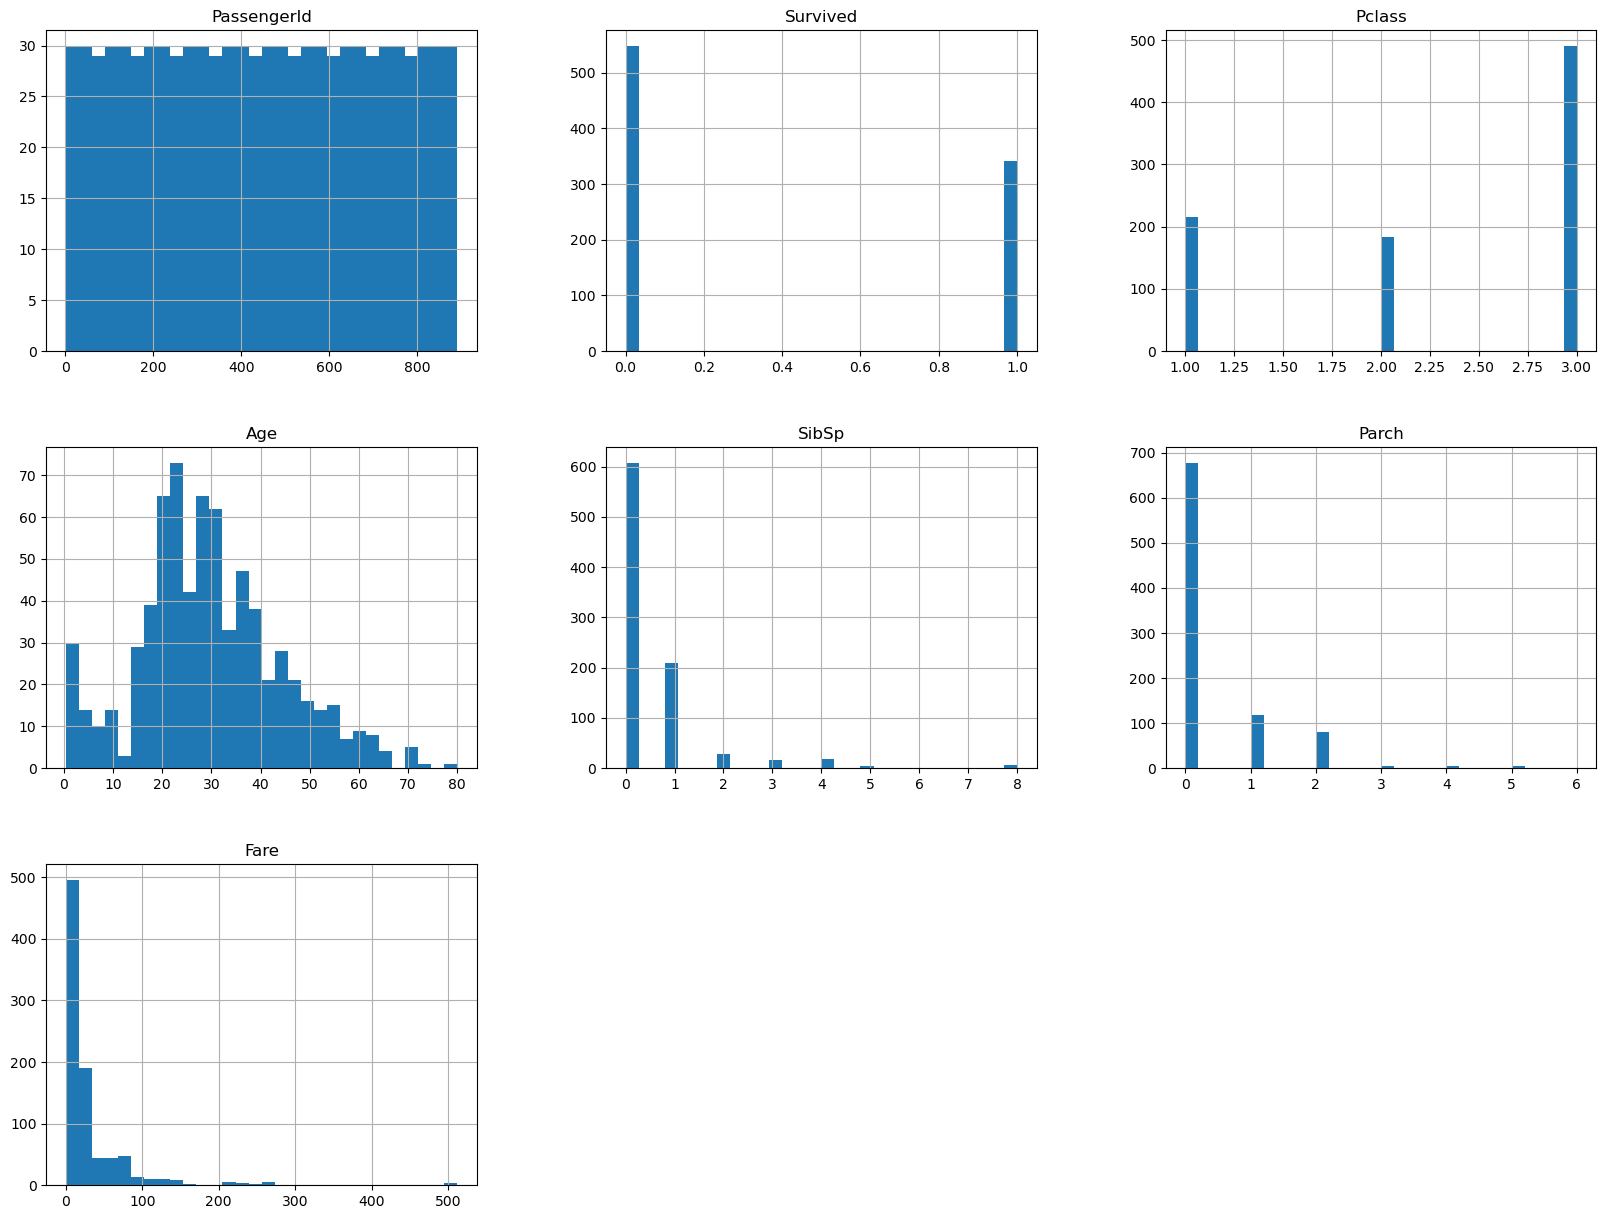

In [12]:
df.hist(bins = 30,figsize = (20,15))
plt.show()

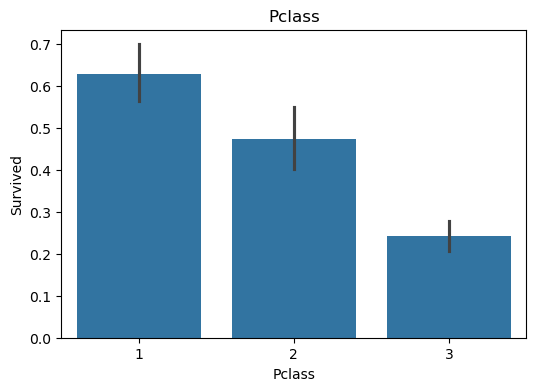

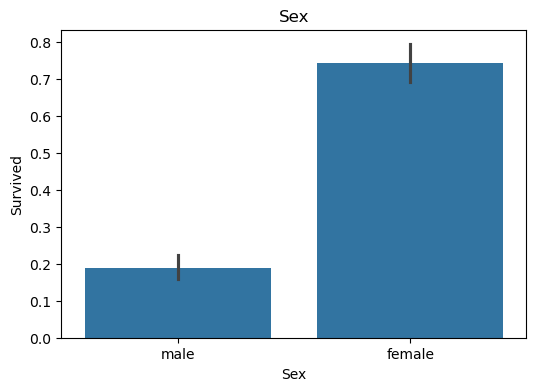

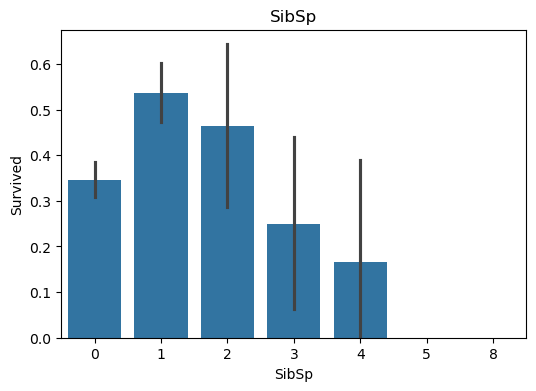

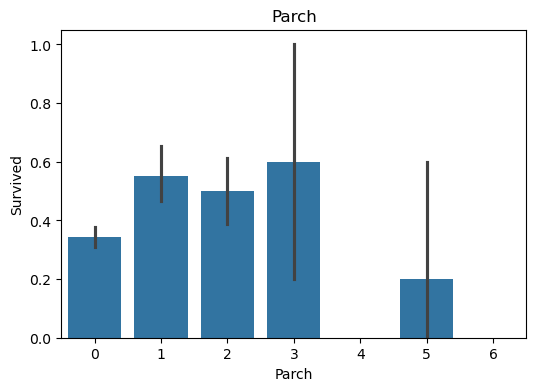

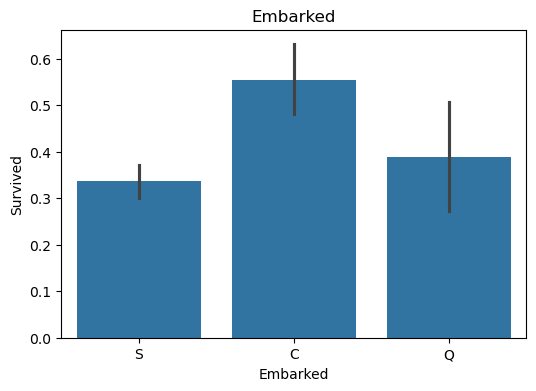

In [13]:
# if one category has many ppl dead and few alive and other has nearby equally dead and alive so can i say that
# category 2 has most ppl survived compared to other categories
# because even though ppl survived in category 1 it still as many ppl who died.
#so i used barplot, A barplot shows survival probability directly.

list = df[['Pclass','Sex','SibSp','Parch','Embarked']]
for col in list: 
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y="Survived", data=df)
    plt.title(col)
    plt.show()


<Axes: xlabel='Embarked', ylabel='count'>

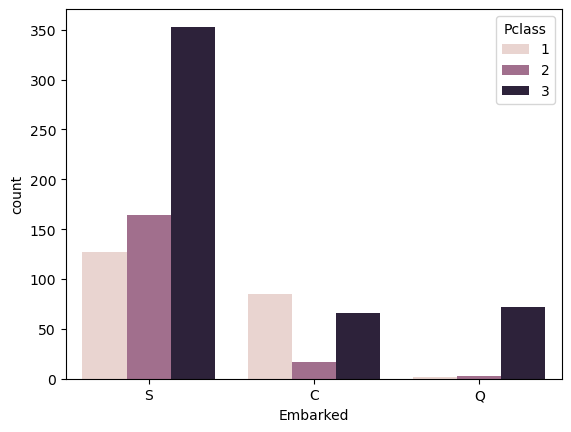

In [14]:
 sns.countplot(x = 'Embarked' ,hue = 'Pclass', data = df)

<Axes: xlabel='Survived', ylabel='Fare'>

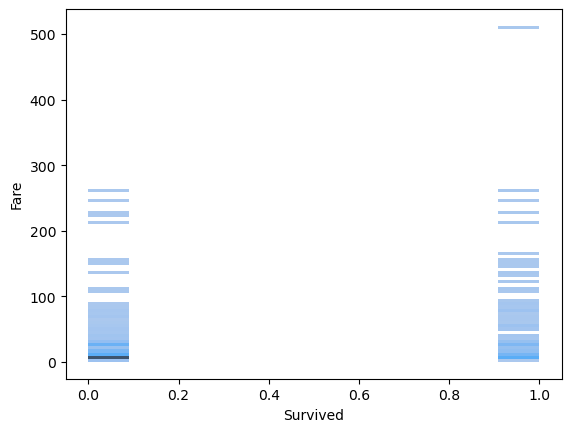

In [15]:
sns.histplot(x = df['Survived'] , y = df['Fare'])

<Axes: xlabel='Survived', ylabel='Age'>

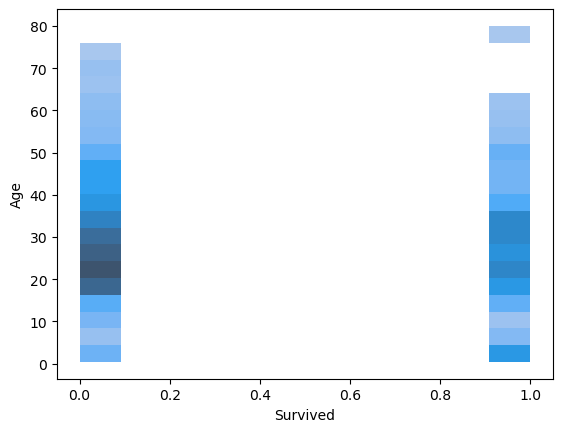

In [16]:
sns.histplot(x = df['Survived'] , y = df['Age'])

<Axes: >

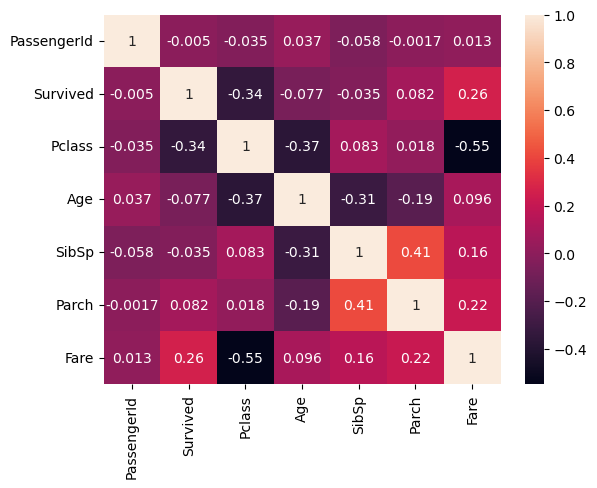

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data cleaning

In [18]:
# dropping these columns to prevent model from learning noise.
df = df.drop(['PassengerId','Name','Ticket', 'Cabin'],axis = 1)

In [19]:
# fill null age values with mean age
df["Age"].fillna(df["Age"].mean(), inplace=True)

C:\Users\vaishnavi\AppData\Local\Temp\ipykernel_17656\3665669436.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [20]:
df['Sex'] = df['Sex'].map({'male' : 0, 'female' : 1})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [21]:
df = pd.get_dummies(df,drop_first = True, dtype = int)

Feature Engineering

In [22]:
#creating new feature by adding 'SibSp' and 'Parch' just so that model can learn more strong insights
df['Familysize'] = df['SibSp'] + df['Parch'] + 1 

In [23]:
df = df.drop(['SibSp','SibSp'],axis = 1)

In [24]:
df.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked_Q,Embarked_S,Familysize
0,0,3,0,22.0,0,7.2500,0,1,2
1,1,1,1,38.0,0,71.2833,0,0,2
2,1,3,1,26.0,0,7.9250,0,1,1
3,1,1,1,35.0,0,53.1000,0,1,2
4,0,3,0,35.0,0,8.0500,0,1,1


<Axes: xlabel='Familysize', ylabel='count'>

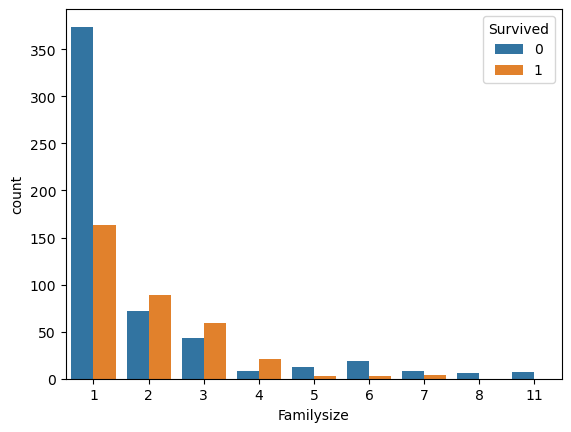

In [25]:
sns.countplot(x = df['Familysize'],hue = df['Survived'])

<Axes: xlabel='Familysize', ylabel='Survived'>

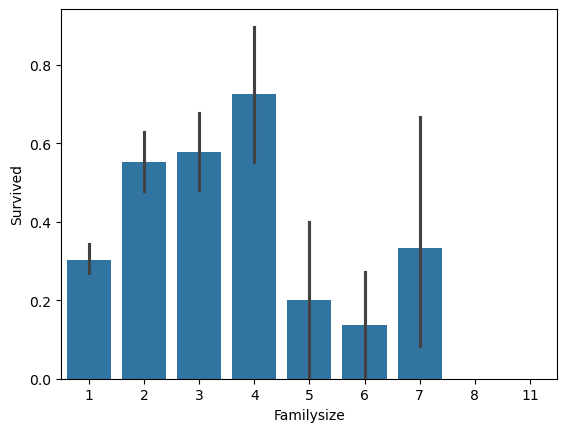

In [26]:
sns.barplot(x="Familysize", y="Survived", data=df)

In [27]:
# tried it but this did not help much
# df["AgeGroup"] = pd.cut(
#     df["Age"],
#     bins=[0,12,18,35,60,80],
#     labels=["Child","Teen","YoungAdult","Adult","Senior"]
# )
# sns.barplot(x="AgeGroup", y="Survived", data=df)

In [28]:
# df = pd.get_dummies(df,drop_first = True, dtype = int)


In [29]:
#'Fare_per_person' because tickets were bought mostly in group, if we understand fare per person, it can capture wealth / class signal more accurately.
df['Fare_per_person'] = df['Fare']/ df['Familysize']

In [30]:
#"IsAlone" can help learn model if survival is more likely when passenger is alone or in group
df["IsAlone"] = (df["Familysize"] == 1).astype(int)
df.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked_Q,Embarked_S,Familysize,Fare_per_person,IsAlone
0,0,3,0,22.0,0,7.2500,0,1,2,3.62500,0
1,1,1,1,38.0,0,71.2833,0,0,2,35.64165,0
2,1,3,1,26.0,0,7.9250,0,1,1,7.92500,1
3,1,1,1,35.0,0,53.1000,0,1,2,26.55000,0
4,0,3,0,35.0,0,8.0500,0,1,1,8.05000,1


Train/Test split

In [31]:
X = df.drop('Survived', axis = 1)
y = df[['Survived']]

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
X_train

,Pclass,Sex,Age,Parch,Fare,Embarked_Q,Embarked_S,Familysize,Fare_per_person,IsAlone
445,1,0,4.000000,2,81.8583,0,1,3,27.286100,0
650,3,0,29.699118,0,7.8958,0,1,1,7.895800,1
172,3,1,1.000000,1,11.1333,0,1,3,3.711100,0
450,2,0,36.000000,2,27.7500,0,1,4,6.937500,0
314,2,0,43.000000,1,26.2500,0,1,3,8.750000,0
...,...,...,...,...,...,...,...,...,...,...
106,3,1,21.000000,0,7.6500,0,1,1,7.650000,1
270,1,0,29.699118,0,31.0000,0,1,1,31.000000,1
860,3,0,41.000000,0,14.1083,0,1,3,4.702767,0
435,1,1,14.000000,2,120.0000,0,1,4,30.000000,0


Feature Scaling

In [35]:
#feature Scaling need to be done after train test split to prevent data leakage
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
Scaled_X_train = scaler.transform(X_train)
Scaled_X_test = scaler.transform(X_test)

Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model_1 = LogisticRegression(max_iter=1000)

In [38]:
model_1.fit(X_train, y_train)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [39]:
y_pred = model_1.predict(X_test)

In [40]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0])

In [41]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [42]:
confusion_matrix(y_test,y_pred)

array([[136,  21],
       [ 32,  79]])

In [43]:
accuracy_score(y_test,y_pred)

0.8022388059701493

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



Training with scaled data

In [45]:
model_1.fit(Scaled_X_train,y_train)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [46]:
y_pred_ = model_1.predict(Scaled_X_test)

In [47]:
confusion_matrix(y_test,y_pred_)

array([[136,  21],
       [ 32,  79]])

In [48]:
accuracy_score(y_test,y_pred_)

0.8022388059701493

In [49]:
print(classification_report(y_test,y_pred_))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



Threshold = 0.4

In [50]:
probs = model_1.predict_proba(Scaled_X_test)[:,1]
preds = (probs >= 0.4).astype(int)

In [51]:
confusion_matrix(y_test,preds)

array([[131,  26],
       [ 26,  85]])

In [52]:
accuracy_score(y_test,preds)

0.8059701492537313

In [53]:
print(classification_report(y_test,preds)) # improvement in recall can be seen after changing threshold

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       157
           1       0.77      0.77      0.77       111

    accuracy                           0.81       268
   macro avg       0.80      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [54]:
model_1.coef_

array([[-0.71646414,  1.18156985, -0.4135696 ,  0.1465286 , -0.06931682,
        -0.01244794, -0.21978457, -0.69624445,  0.22655233, -0.37347859]])

Cross validation on logistic regression

In [55]:
from sklearn.model_selection import cross_val_score

In [56]:
scores = cross_val_score(model_1, Scaled_X_train, y_train, cv=5)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of 

In [57]:
print(scores)
print(scores.mean())

[0.776      0.88       0.776      0.75806452 0.82258065]
0.8025290322580645


K-Nearest Neighour

In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [60]:
knn_model.fit(Scaled_X_train,y_train)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [61]:
y_pred_knn = knn_model.predict(Scaled_X_test)

In [62]:
accuracy_score(y_test,y_pred_knn)

0.7947761194029851

In [63]:
confusion_matrix(y_test,y_pred_knn)

array([[137,  20],
       [ 35,  76]])

In [64]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       157
           1       0.79      0.68      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



Decision Tree

In [65]:
from sklearn.tree import DecisionTreeClassifier

In [66]:
desc_tree_model = DecisionTreeClassifier(max_depth = 3)

In [67]:
desc_tree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [68]:
tree_pred = desc_tree_model.predict(X_test)

In [69]:
confusion_matrix(y_test,tree_pred)

array([[140,  17],
       [ 33,  78]])

In [70]:
print(classification_report(y_test,tree_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       157
           1       0.82      0.70      0.76       111

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [71]:
desc_tree_model.feature_importances_

array([0.17813072, 0.57999044, 0.08449531, 0.        , 0.05416996,
       0.        , 0.        , 0.04702514, 0.05618843, 0.        ])

Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rfc = RandomForestClassifier(n_estimators = 200,random_state = 101)

In [74]:
rfc.fit(X_train,y_train)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=200, random_state=101)

In [75]:
rfc_pred = rfc.predict(X_test)

In [76]:
rfc_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0])

In [77]:
accuracy_score(y_test,rfc_pred)

0.7835820895522388

In [78]:
confusion_matrix(y_test,rfc_pred)

array([[131,  26],
       [ 32,  79]])

In [79]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.71      0.73       111

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.78      0.78      0.78       268



cross validation on random Forest

In [80]:
scores = cross_val_score(rfc, X_train, y_train, cv=5)

C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\vaishnavi\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (

In [81]:
print(scores)
print(scores.mean())

[0.816      0.776      0.752      0.7983871  0.87096774]
0.8026709677419355


conslusion:
Logistic Regression performed best with recall = 0.77 after threshold tuning.
This suggests linear relationships dominate survival prediction.